In [1]:
import pandas as pd
df = pd.read_parquet('../data/persons.parquet')


In [2]:
df

,original_index,position,type,status,gender,age,age_group,name
id,,,,,,,,
461105p0,461105,0,Victim,Arrested,Male,20.0,Adult 18+,Julian Sims
461105p1,461105,1,Victim,Injured,Male,NaN,Adult 18+,NaN
461105p2,461105,2,Victim,Injured,NaN,NaN,Adult 18+,NaN
461105p3,461105,3,Victim,Injured,Male,NaN,Adult 18+,NaN
461105p4,461105,4,Subject-Suspect,Injured,Female,NaN,Adult 18+,NaN
...,...,...,...,...,...,...,...,...
1083139p1,1083139,1,Subject-Suspect,"Unharmed, Arrested",Male,21.0,Adult 18+,Jaquarious Tyjuan Ardison
1083151p0,1083151,0,Victim,Injured,Male,21.0,Adult 18+,NaN
1082514p0,1082514,0,Victim,Killed,Male,42.0,Adult 18+,Leroy Ellis


In [3]:
df_clear = df

In [4]:
df_clear.dropna(inplace=True)

In [5]:
df_clear[100:130]

,original_index,position,type,status,gender,age,age_group,name
id,,,,,,,,
483835p0,483835,0,Victim,Killed,Male,18.0,Adult 18+,Bernabed Hernandez-Canela
483835p1,483835,1,Victim,Killed,Male,19.0,Adult 18+,Matthew Fisher
483835p2,483835,2,Victim,Killed,Female,16.0,Teen 12-17,Samantha Parreira
483835p5,483835,5,Subject-Suspect,"Unharmed, Arrested",Male,19.0,Adult 18+,Jose Luis Botello
483835p6,483835,6,Subject-Suspect,"Unharmed, Arrested",Male,20.0,Adult 18+,Jose M. Carballido
483817p0,483817,0,Victim,Killed,Male,23.0,Adult 18+,Lorenzo Duncan
483817p1,483817,1,Victim,Killed,Male,21.0,Adult 18+,Antuan Greer
483817p2,483817,2,Victim,Killed,Male,25.0,Adult 18+,Nicholas Lindsay
483817p4,483817,4,Subject-Suspect,"Injured, Arrested",Male,29.0,Adult 18+,Cleanthony Baby Ray Jimerson


In [6]:
drop_statuses = [
    "Killed, Arrested",
    "Injured, Unharmed",
    "Injured, Unharmed, Arrested",
    "Killed, Unharmed",
    "Killed, Unharmed, Arrested",
    "Killed, Injured",
]

df_clear = df_clear[~df_clear["status"].isin(drop_statuses)]

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# 1. Drop the columns we don't want as features (keep `type` — that's the target)
data = df_clear[["type", "status", "gender", "age"]].dropna()

# 2. Encode categorical features (status, gender) — one-hot encoding
X = pd.get_dummies(data[["status", "gender", "age"]], columns=["status", "gender"])
y = data["type"]

# 3. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 4. Fit Random Forest
clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

# 5. Evaluate
y_pred = clf.predict(X_test)
print(f"Test accuracy: {clf.score(X_test, y_test):.3f}\n")
print("Classification report:")
print(classification_report(y_test, y_pred))
print("Confusion matrix (rows=true, cols=predicted):")
print(pd.DataFrame(confusion_matrix(y_test, y_pred, labels=clf.classes_),
                   index=[f"true_{c}" for c in clf.classes_],
                   columns=[f"pred_{c}" for c in clf.classes_]))

# 6. Feature importance — which columns mattered most
importance = (pd.Series(clf.feature_importances_, index=X.columns)
              .sort_values(ascending=False)
              .head(15))
print("\nTop 15 feature importances:")
print(importance.round(4))

Test accuracy: 0.926

Classification report:
                 precision    recall  f1-score   support

Subject-Suspect       0.97      0.91      0.94     24730
         Victim       0.86      0.95      0.90     14357

       accuracy                           0.93     39087
      macro avg       0.92      0.93      0.92     39087
   weighted avg       0.93      0.93      0.93     39087

Confusion matrix (rows=true, cols=predicted):
                      pred_Subject-Suspect  pred_Victim
true_Subject-Suspect                 22482         2248
true_Victim                            651        13706

Top 15 feature importances:
status_Killed                0.4020
status_Unharmed, Arrested    0.2691
status_Injured               0.1835
status_Unharmed              0.0755
status_Arrested              0.0316
age                          0.0195
status_Injured, Arrested     0.0075
gender_Female                0.0057
gender_Male                  0.0057
dtype: float64


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# 1. Drop the columns we don't want as features (keep `type` — that's the target)
data = df_clear[["type", "status", "gender", "age"]].dropna()

# 2. Encode categorical features
X = pd.get_dummies(data[["status", "gender", "age"]], columns=["status", "gender"])
y = data["type"]

# 3. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 4. Fit a single Decision Tree
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# 5. Evaluate — same as before
y_pred = clf.predict(X_test)
print(f"Test accuracy: {clf.score(X_test, y_test):.3f}\n")
print("Classification report:")
print(classification_report(y_test, y_pred))
print("Confusion matrix (rows=true, cols=predicted):")
print(pd.DataFrame(confusion_matrix(y_test, y_pred, labels=clf.classes_),
                   index=[f"true_{c}" for c in clf.classes_],
                   columns=[f"pred_{c}" for c in clf.classes_]))

# 6. Feature importance
importance = (pd.Series(clf.feature_importances_, index=X.columns)
              .sort_values(ascending=False)
              .head(15))
print("\nTop 15 feature importances:")
print(importance.round(4))

Test accuracy: 0.925

Classification report:
                 precision    recall  f1-score   support

Subject-Suspect       0.97      0.91      0.94     24730
         Victim       0.86      0.95      0.90     14357

       accuracy                           0.93     39087
      macro avg       0.92      0.93      0.92     39087
   weighted avg       0.93      0.93      0.93     39087

Confusion matrix (rows=true, cols=predicted):
                      pred_Subject-Suspect  pred_Victim
true_Subject-Suspect                 22501         2229
true_Victim                            689        13668

Top 15 feature importances:
status_Killed                0.6002
status_Injured               0.3812
age                          0.0083
gender_Male                  0.0057
status_Unharmed, Arrested    0.0028
status_Injured, Arrested     0.0013
status_Unharmed              0.0004
status_Arrested              0.0000
gender_Female                0.0000
dtype: float64


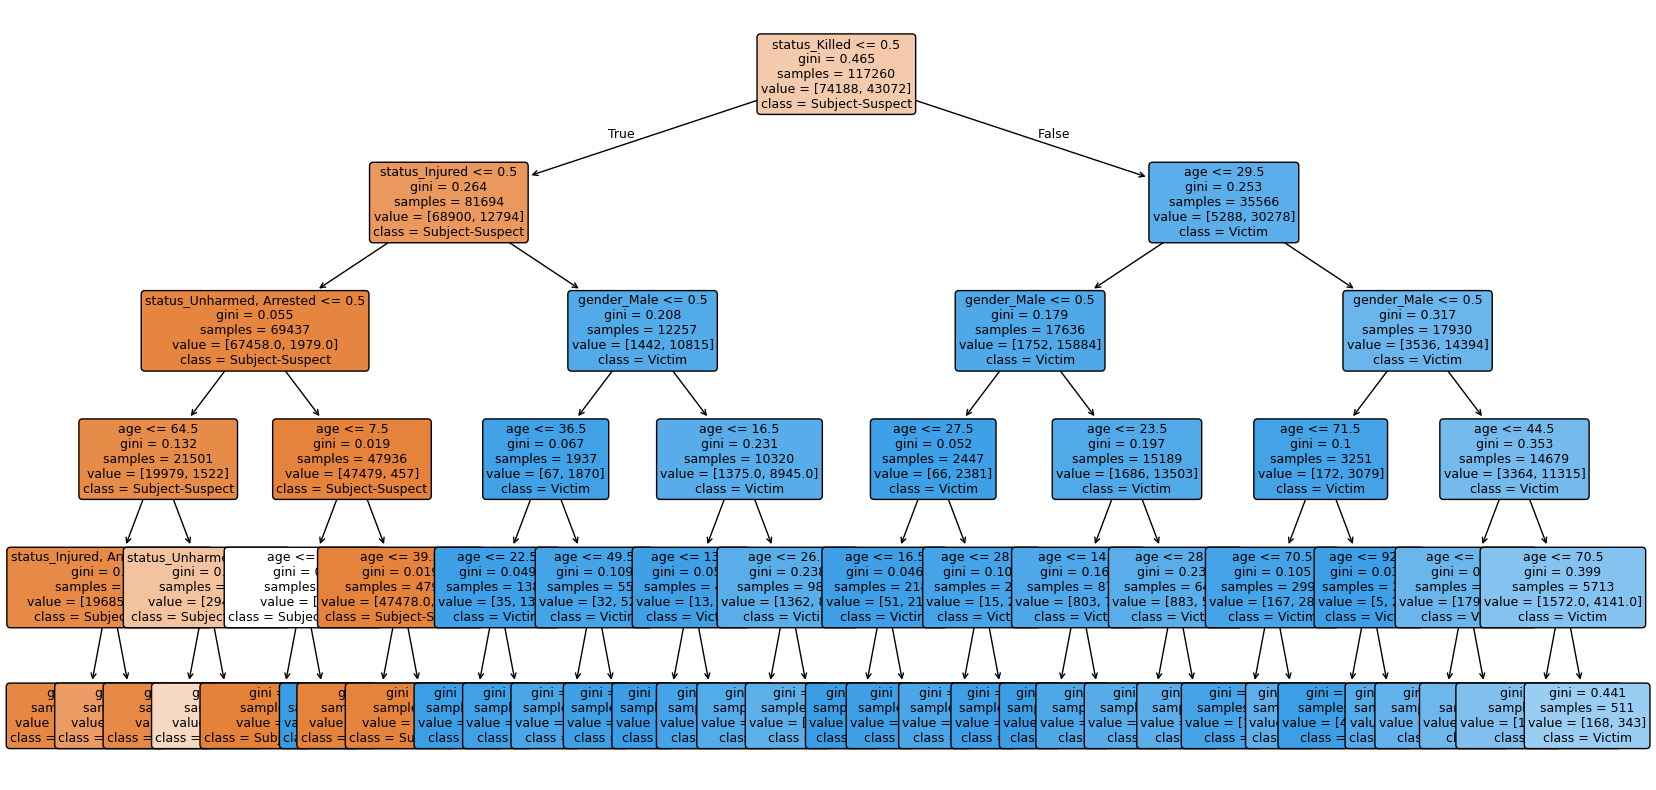

|--- status_Killed <= 0.50
|   |--- status_Injured <= 0.50
|   |   |--- status_Unharmed, Arrested <= 0.50
|   |   |   |--- age <= 64.50
|   |   |   |   |--- status_Injured, Arrested <= 0.50
|   |   |   |   |   |--- class: Subject-Suspect
|   |   |   |   |--- status_Injured, Arrested >  0.50
|   |   |   |   |   |--- class: Subject-Suspect
|   |   |   |--- age >  64.50
|   |   |   |   |--- status_Unharmed <= 0.50
|   |   |   |   |   |--- class: Subject-Suspect
|   |   |   |   |--- status_Unharmed >  0.50
|   |   |   |   |   |--- class: Subject-Suspect
|   |   |--- status_Unharmed, Arrested >  0.50
|   |   |   |--- age <= 7.50
|   |   |   |   |--- age <= 2.50
|   |   |   |   |   |--- class: Subject-Suspect
|   |   |   |   |--- age >  2.50
|   |   |   |   |   |--- class: Victim
|   |   |   |--- age >  7.50
|   |   |   |   |--- age <= 39.50
|   |   |   |   |   |--- class: Subject-Suspect
|   |   |   |   |--- age >  39.50
|   |   |   |   |   |--- class: Subject-Suspect
|   |--- status_Injure

In [11]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree, export_text

# Visual tree (graphical)
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(clf,
          feature_names=X.columns,
          class_names=clf.classes_,
          filled=True,
          rounded=True,
          fontsize=9,
          ax=ax)
plt.show()

# OR a text version (easier to read if the tree is small)
print(export_text(clf, feature_names=list(X.columns)))

In [33]:
data = df_clear[["type", "status", "gender", "age"]].dropna()

# 2. Encode categorical features
X = pd.get_dummies(data[["status", "gender", "age"]], columns=["status", "gender"])
y = data["type"]

# 3. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=43, stratify=y
)

# 4. Fit a single Decision Tree
clf = DecisionTreeClassifier(max_depth=2, random_state=48)
clf.fit(X_train, y_train)

# 5. Evaluate — same as before
y_pred = clf.predict(X_test)
print(f"Test accuracy: {clf.score(X_test, y_test):.3f}\n")
print("Classification report:")
print(classification_report(y_test, y_pred))
print("Confusion matrix (rows=true, cols=predicted):")
print(pd.DataFrame(confusion_matrix(y_test, y_pred, labels=clf.classes_),
                   index=[f"true_{c}" for c in clf.classes_],
                   columns=[f"pred_{c}" for c in clf.classes_]))

# 6. Feature importance
importance = (pd.Series(clf.feature_importances_, index=X.columns)
              .sort_values(ascending=False)
              .head(15))
print("\nTop 15 feature importances:")

Test accuracy: 0.927

Classification report:
                 precision    recall  f1-score   support

Subject-Suspect       0.97      0.91      0.94     24730
         Victim       0.86      0.96      0.91     14357

       accuracy                           0.93     39087
      macro avg       0.92      0.93      0.92     39087
   weighted avg       0.93      0.93      0.93     39087

Confusion matrix (rows=true, cols=predicted):
                      pred_Subject-Suspect  pred_Victim
true_Subject-Suspect                 22513         2217
true_Victim                            642        13715

Top 15 feature importances:


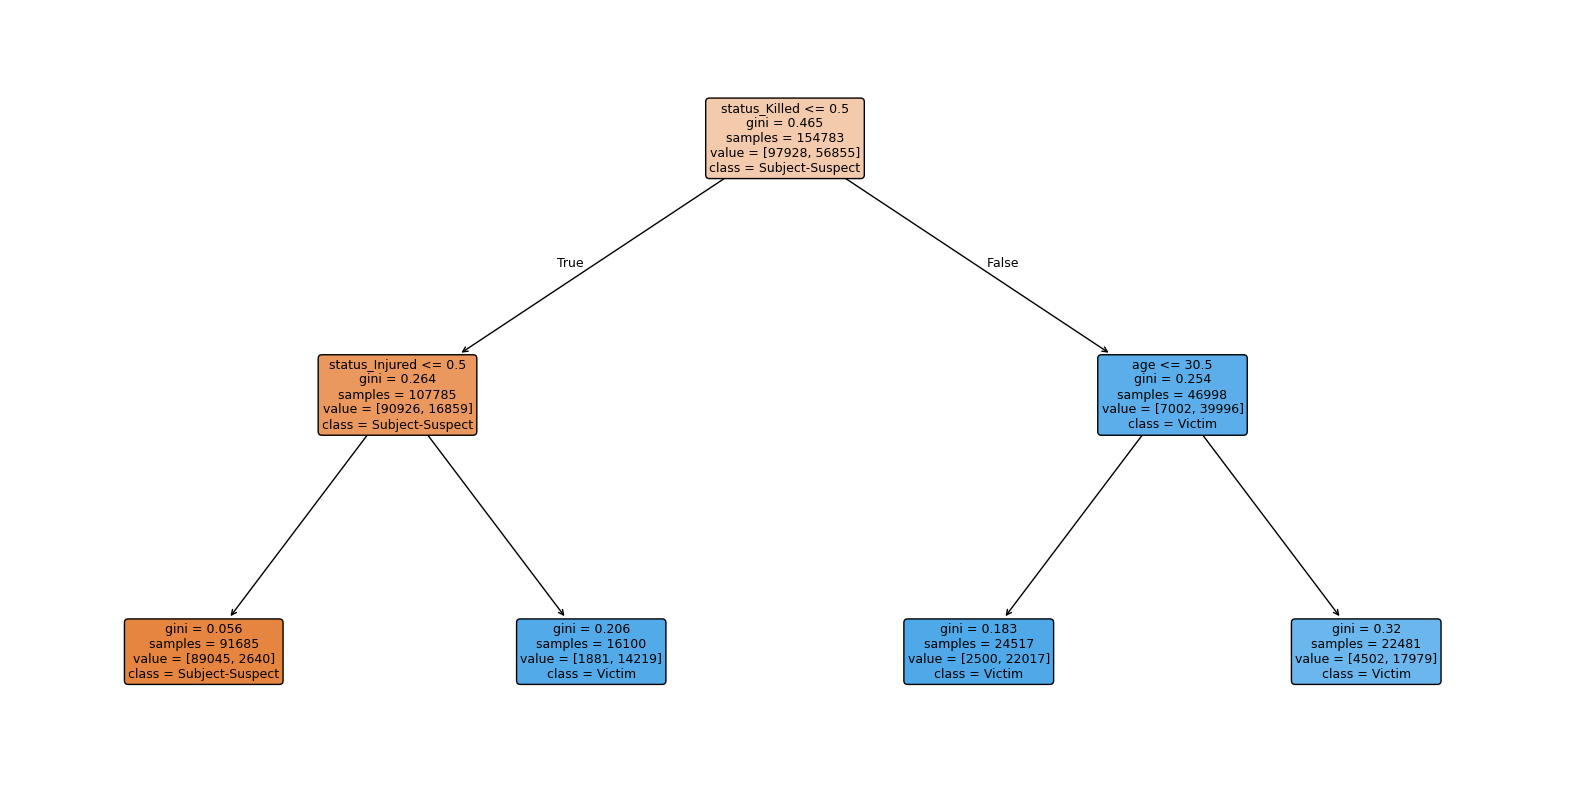

|--- status_Killed <= 0.50
|   |--- status_Injured <= 0.50
|   |   |--- class: Subject-Suspect
|   |--- status_Injured >  0.50
|   |   |--- class: Victim
|--- status_Killed >  0.50
|   |--- age <= 30.50
|   |   |--- class: Victim
|   |--- age >  30.50
|   |   |--- class: Victim



In [32]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(clf,
          feature_names=X.columns,
          class_names=clf.classes_,
          filled=True,
          rounded=True,
          fontsize=9,
          ax=ax)
plt.show()

# OR a text version (easier to read if the tree is small)
print(export_text(clf, feature_names=list(X.columns)))

A random forrest, a tree with max depth from 2 to 7 gives basicaly the same results on a 25% stratified test set.
So the smallest tree is the best because it is simple. If a person is killed and then if a person is injured there is about 

In [9]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Pick categorical columns and drop NaNs
cat_cols = ["type", "status", "gender", "age_group"]
data = df[cat_cols].dropna()

# 2. Convert each row to a list of "column=value" tokens (so rules are readable)
transactions = data.apply(
    lambda row: [f"{col}={val}" for col, val in row.items()], axis=1
).tolist()

# 3. One-hot encode into the boolean matrix Apriori expects
te = TransactionEncoder()
encoded_array = te.fit_transform(transactions)
encoded_df = pd.DataFrame(encoded_array, columns=te.columns_)

# 4. Find frequent itemsets (min_support = minimum fraction of rows the itemset appears in)
frequent_itemsets = apriori(encoded_df, min_support=0.02, use_colnames=True)
print(f"Found {len(frequent_itemsets)} frequent itemsets")

# 5. Generate association rules (filter by confidence)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)
rules = rules.sort_values("lift", ascending=False)

# 6. Show the most interesting rules
print(rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(20))

Found 74 frequent itemsets
                                           antecedents  \
77           frozenset({gender=Female, status=Killed})   
99   frozenset({age_group=Adult 18+, gender=Female,...   
102          frozenset({gender=Female, status=Killed})   
121                        frozenset({status=Injured})   
118   frozenset({age_group=Adult 18+, status=Injured})   
85                         frozenset({status=Injured})   
59                         frozenset({status=Injured})   
21                         frozenset({status=Injured})   
119           frozenset({gender=Male, status=Injured})   
57    frozenset({age_group=Adult 18+, status=Injured})   
83            frozenset({gender=Male, status=Injured})   
115  frozenset({age_group=Adult 18+, gender=Male, s...   
98   frozenset({age_group=Adult 18+, type=Victim, g...   
76             frozenset({type=Victim, gender=Female})   
22                            frozenset({type=Victim})   
23                          frozenset({status

The association rules tell us mostly that if a person is a killed or injured that means that most likely (88%) he or she is a victim. Moreover, if a person is killed and is a woman she has a higher (95%) chance of being a victim. These info are not something special although.